# TOPIC 1: INVESTMENT AND ACCESS TO EDUCATION

## 1. Basic Data Analysis

### 1.1. Overview of the Dataset

The dataset used in this analysis is collected from the **World Development Indicators (WDI)** provided by the World Bank. The data includes information from **12 countries** with diverse income levels and geographic regions, during the period from **2015 to 2022**.

The countries analyzed are: Brazil, France, Germany, India, Indonesia, Japan, Korea (Rep.), Singapore, South Africa, United Kingdom, United States, Viet Nam.

**Reason for selecting these 12 countries:** to create a comparative context to **draw lessons and development strategies for education in Viet Nam**, from both developed and developing countries with different levels of investment and access to education.

### 1.2. Data Structure and Fields

| Column | Description |
|-----|--------|
| Country Name | Country name |
| Country Code | Country code (ISO 3-letter) |
| Series Name | Indicator name |
| Series Code | Indicator code |
| 2015 [YR2015] ... 2022 [YR2022] | Indicator values by year |

Each country has **3 indicators (Series):**

1. **`NY.GDP.PCAP.CD`** - GDP per capita (current US$): GDP per capita at current prices (USD).
2. **`SE.TER.ENRR`** - School enrollment, tertiary (% gross): Gross tertiary enrollment rate (%). This indicator = [Total tertiary enrollment regardless of age] / [Population of official tertiary education age] × 100. The value can be >100% when there are many students outside the official age group.
3. **`SE.XPD.TOTL.GD.ZS`** - Government expenditure on education, total (% of GDP): Total government public expenditure on education as a percentage of GDP.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plot parameters
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

# 1. Read data from the main file and filter by initial years
DATA_PATH = '../data3/dataset.csv'  # Path to the dataset
df_raw_full = pd.read_csv(DATA_PATH, encoding='utf-8-sig')

# List of indicators needed for Topic 1 / Education Investment and Access
EDU_INDICATORS = [
    'NY.GDP.PCAP.CD',
    'SE.TER.ENRR',
    'SE.XPD.TOTL.GD.ZS'
]

# Select 12 countries based on the original Topic 1 list
SELECTED_COUNTRIES = ['BRA', 'FRA', 'DEU', 'IND', 'IDN', 'JPN', 'KOR', 'SGP', 'ZAF', 'GBR', 'USA', 'VNM']

# 2. Data preprocessing: Select required columns (also filter for years 2015-2022 in Wide format)
year_cols = [f"{year} [YR{year}]" for year in range(2015, 2023)]
base_cols = ['Country Name', 'Country Code', 'Series Name', 'Series Code']

# Filter dataset (indicators, countries, and years)
df_raw = df_raw_full[
    (df_raw_full['Series Code'].isin(EDU_INDICATORS)) & 
    (df_raw_full['Country Code'].isin(SELECTED_COUNTRIES))
][base_cols + year_cols].copy()

# Convert from Wide to Long format
df_long = df_raw.melt(
    id_vars=base_cols,
    value_vars=year_cols,
    var_name='YearRaw', value_name='Value'
)

# Extract year number (e.g., "2015 [YR2015]" -> 2015)
df_long['Year'] = df_long['YearRaw'].str.extract(r'(\d{4})').astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')
df_long = df_long.sort_values(by=['Country Code', 'Series Code', 'Year']).reset_index(drop=True)

print(f"Initial table size after filtering: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Number of records after conversion: {len(df_long)}")
print(f"Number of missing values (NaN): {df_long['Value'].isna().sum()}")
print(f"Countries: {sorted(df_long['Country Name'].unique())}")
df_long.head()

Initial table size after filtering: 36 rows × 12 columns
Number of records after conversion: 288
Number of missing values (NaN): 8
Countries: ['Brazil', 'France', 'Germany', 'India', 'Indonesia', 'Japan', 'Korea, Rep.', 'Singapore', 'South Africa', 'United Kingdom', 'United States', 'Viet Nam']


,Country Name,Country Code,Series Name,Series Code,YearRaw,Value,Year
0,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,2015 [YR2015],8936.195589,2015
1,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,2016 [YR2016],8836.285460,2016
2,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,2017 [YR2017],10080.507872,2017
3,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,2018 [YR2018],9300.660729,2018
4,Brazil,BRA,GDP per capita (current US$),NY.GDP.PCAP.CD,2019 [YR2019],9029.833044,2019


In [22]:
# 3. Detailed check for missing data
missing_detail = df_long[df_long['Value'].isna()][['Country Name', 'Series Code', 'Year']]
if len(missing_detail) > 0:
    print("Missing data cells (NaN):")
    print(missing_detail.to_string(index=False))
else:
    print("No missing data found.")

Missing data cells (NaN):
  Country Name       Series Code  Year
        France SE.XPD.TOTL.GD.ZS  2015
        France SE.XPD.TOTL.GD.ZS  2016
United Kingdom SE.XPD.TOTL.GD.ZS  2022
         Japan SE.XPD.TOTL.GD.ZS  2022
     Singapore       SE.TER.ENRR  2015
 United States SE.XPD.TOTL.GD.ZS  2022
      Viet Nam       SE.TER.ENRR  2018
      Viet Nam       SE.TER.ENRR  2020


In [23]:
# 4. Handle missing data using linear interpolation within each (country, indicator) group
df_clean = df_long.copy()
df_clean['Value'] = df_clean.groupby(['Country Code', 'Series Code'])['Value'].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

print(f"Number of missing values after processing: {df_clean['Value'].isna().sum()}")

Number of missing values after processing: 0


In [24]:
# 5. Basic statistics for each indicator
for code in sorted(df_clean['Series Code'].unique()):
    subset = df_clean[df_clean['Series Code'] == code]
    name = subset['Series Name'].iloc[0]
    print(f"\n--- {code}: {name} ---")
    print(subset['Value'].describe().to_string())


--- NY.GDP.PCAP.CD: GDP per capita (current US$) ---
count       96.000000
mean     29864.462142
std      23563.222294
min       1583.998159
25%       5368.161585
50%      35162.295104
75%      45329.992229
max      90299.069464

--- SE.TER.ENRR: School enrollment, tertiary (% gross) ---
count     96.000000
mean      59.523048
std       24.418201
min       18.929298
25%       36.059109
50%       62.467819
75%       79.452719
max      102.813057

--- SE.XPD.TOTL.GD.ZS: Government expenditure on education, total (% of GDP) ---
count    96.000000
mean      4.375895
std       1.428398
min       0.863943
25%       3.303560
50%       4.780795
75%       5.455635
max       6.555170


## Handling Missing Data

In the dataset, the group identified some missing values (NaN) scattered throughout, for example:

- Missing **education expenditure (% GDP)** in France (2015–2016), United Kingdom (2022), Japan (2022), United States (2022)  
- Missing **tertiary enrollment rate** in Singapore (2015) and Viet Nam (2018, 2020)

---

## Processing Method

The group used **_linear interpolation_** for each *(country, indicator)* to fill in the missing values.

---

## Reason for Selection

- **_Time-series data_** → the indicators change quite **smoothly over time**, so values can be estimated based on neighboring years  
- **_Very small missing rate_** (8/288) → does not significantly affect the overall trend  
- **_Local missing data_** → each country/indicator is missing only in **a few individual years (maximum 2 years)**, with no long consecutive gaps  
- **_Data retention_** → avoids dropping rows, ensuring sufficient data for visualization and analysis  

---

## Limitations

Interpolation is only an **_estimation_**, so it may slightly deviate from actual values. However, since the missing data is minimal and not continuous, the group considers this impact to be **negligible**.

## 2. Defining Objectives and Selecting Data Fields

### 2.1. Objective 1: Compare trends and the level of national budget priority for education

**SMART Criteria:**
- **S (Specific):** Evaluate investment efforts through government expenditure on education (% of GDP).
- **M (Measurable):** Based on continuous yearly data of the variable `SE.XPD.TOTL.GD.ZS`.
- **A (Achievable):** Fully computable using available data from 12 countries in the dataset.
- **R (Relevant):** Reflects the overall picture of government "education investment".
- **T (Time-bound):** From 2015 to 2022.

### Data Field Used

**`SE.XPD.TOTL.GD.ZS` - Government expenditure on education, total (% of GDP)**
- This indicator measures total government spending (including central and local levels) on education, expressed as a percentage of GDP.
- **Calculation method:** [Total public expenditure on education at all levels] / [GDP] × 100
- This indicator reflects the level of government commitment and priority toward education development relative to the size of the economy.
- **Note:** Only includes **public expenditure** (state budget), excluding private spending (tuition fees paid by households).

### Reason for Selecting the Metric

The variable `SE.XPD.TOTL.GD.ZS` is selected because it is **standardized by economic size** (% of GDP), allowing fair comparisons between rich and poor countries. A country with a small GDP but a high share of education spending (such as Viet Nam ~ 3–3.5%) indicates a relatively greater investment effort compared to a wealthy country that spends less (such as Singapore ~ 2.5–3%).

### 2.1.1. Trend of Education Expenditure (% of GDP) Over the Years

**Reason for choosing a Line Chart:**  
Line Chart is the most standard format for tracking **time-series data**. It allows easy comparison of:
- Slope (rate of change) between countries
- Relative position (which country invests more)
- Overall trend: increasing, decreasing, or stable

Our team used **highlight Min/Max** on each line to emphasize the country with the highest and lowest investment at each point in time.

### 2.1.2. Chart 2: Boxplot — Distribution of Education Expenditure by Income Group

**Reason for choosing a Boxplot:**  
Boxplot helps visualize **distribution boundaries, standard deviation, median, and outlier investment levels** for each income group. Examining by income group instead of individual countries allows us to assess the degree of disparity in education investment and how the economy influences this distribution.

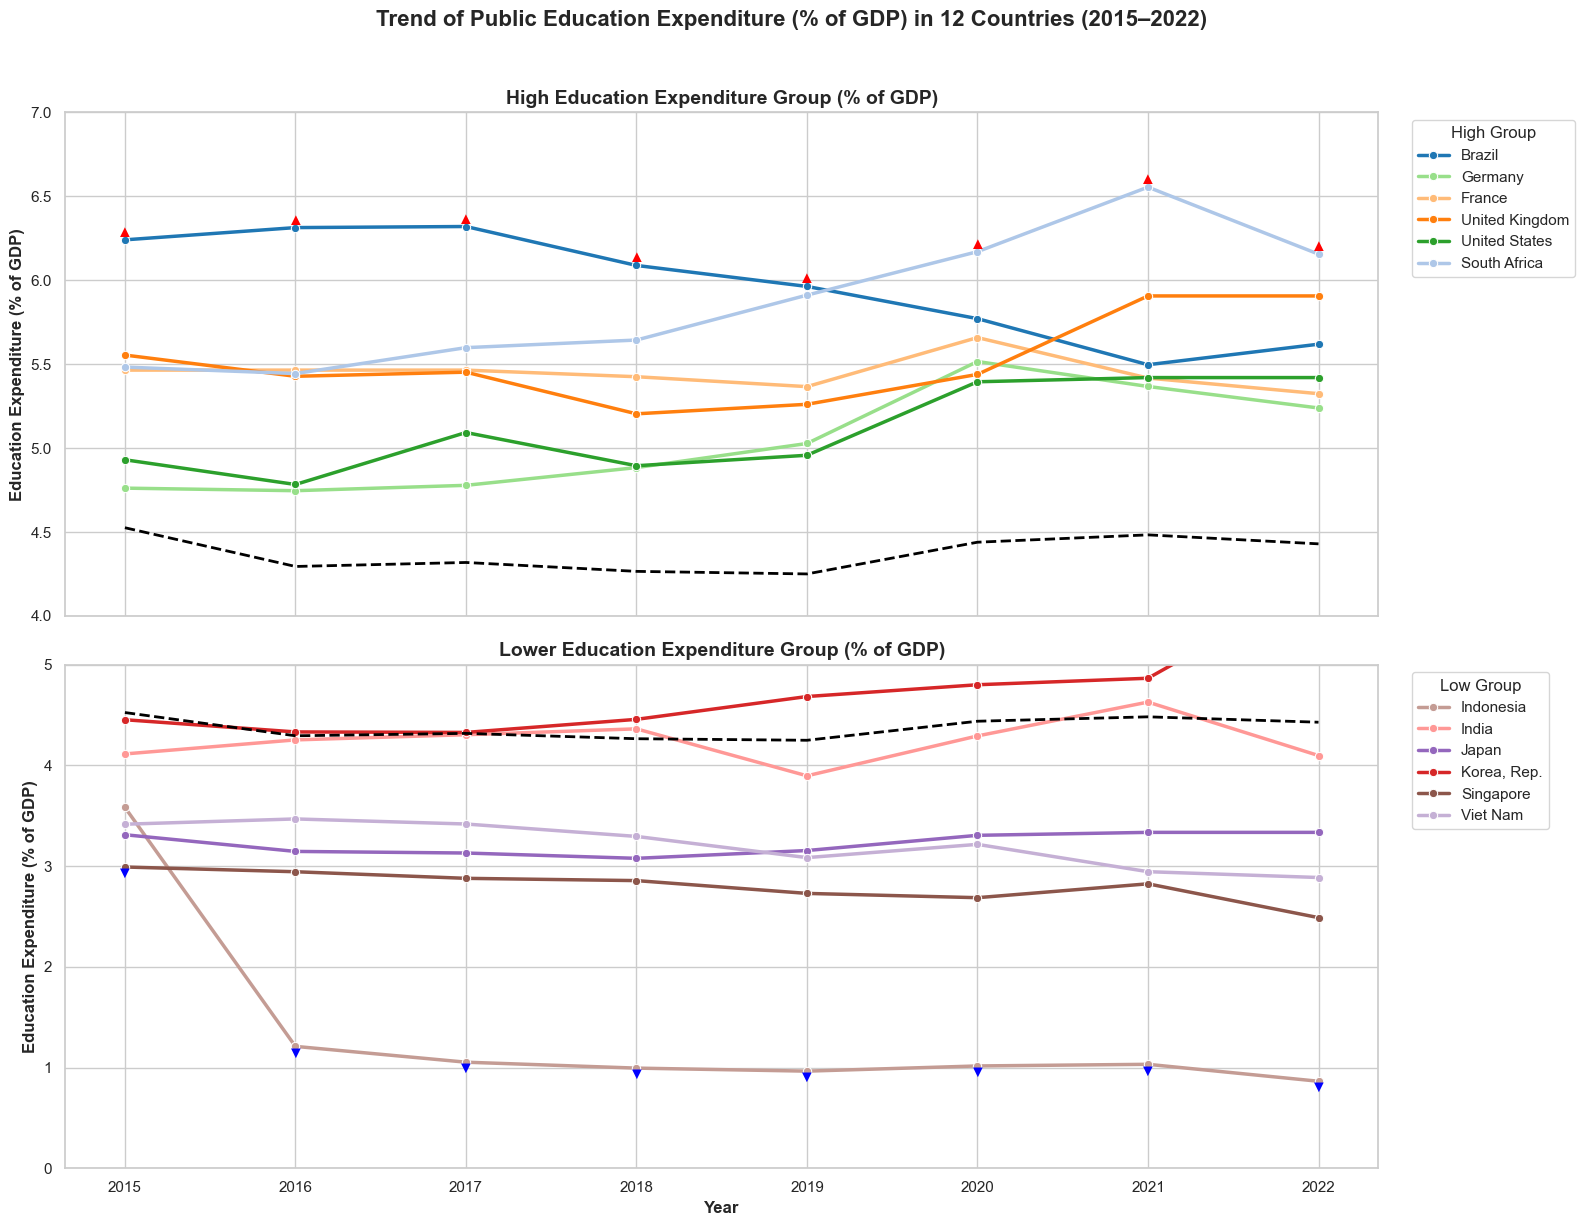

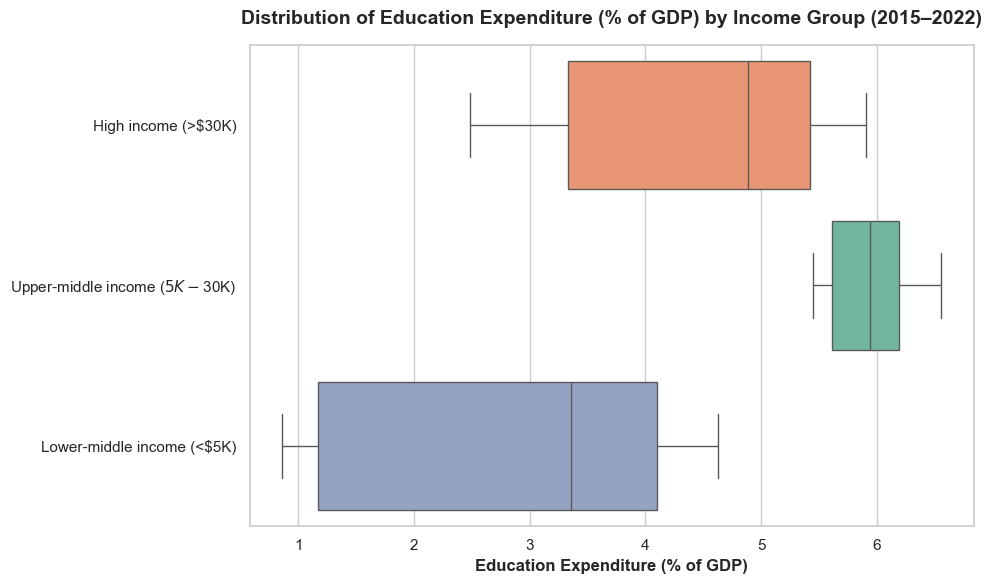


Income group table:
  Singapore            | Average GDP/capita: $67,311 | Group: High income (>$30K)
  United States        | Average GDP/capita: $63,934 | Group: High income (>$30K)
  Germany              | Average GDP/capita: $47,157 | Group: High income (>$30K)
  United Kingdom       | Average GDP/capita: $43,732 | Group: High income (>$30K)
  France               | Average GDP/capita: $39,765 | Group: High income (>$30K)
  Japan                | Average GDP/capita: $38,441 | Group: High income (>$30K)
  Korea, Rep.          | Average GDP/capita: $33,685 | Group: High income (>$30K)
  Brazil               | Average GDP/capita: $8,814 | Group: Upper-middle income ($5K-$30K)
  South Africa         | Average GDP/capita: $6,347 | Group: Upper-middle income ($5K-$30K)
  Indonesia            | Average GDP/capita: $3,931 | Group: Lower-middle income (<$5K)
  Viet Nam             | Average GDP/capita: $3,290 | Group: Lower-middle income (<$5K)
  India                | Average GDP/capita: 

In [25]:
# ====== CHART 1: LINE CHART — Education Expenditure (% of GDP) ======

# Filter education expenditure data
edu_df = df_clean[df_clean['Series Code'] == 'SE.XPD.TOTL.GD.ZS'].copy()

# Tách thành 2 nhóm dựa trên giá trị trung bình để đường không bị chồng chéo
avg_exp = edu_df.groupby('Country Name')['Value'].mean().sort_values(ascending=False)
high_exp_countries = avg_exp.index[:6]
low_exp_countries = avg_exp.index[6:]

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

palette = sns.color_palette('tab20', n_colors=len(edu_df['Country Name'].unique()))
color_map = dict(zip(avg_exp.index, palette))

# Vẽ nhóm chi tiêu cao
sns.lineplot(
    data=edu_df[edu_df['Country Name'].isin(high_exp_countries)],
    x='Year', y='Value', hue='Country Name',
    marker='o', markersize=6, linewidth=2.5, palette=color_map, ax=axes[0]
)
axes[0].set_title('High Education Expenditure Group (% of GDP)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='High Group')
axes[0].set_ylim(4, 7)

# Vẽ nhóm chi tiêu thấp
sns.lineplot(
    data=edu_df[edu_df['Country Name'].isin(low_exp_countries)],
    x='Year', y='Value', hue='Country Name',
    marker='o', markersize=6, linewidth=2.5, palette=color_map, ax=axes[1]
)
axes[1].set_title('Lower Education Expenditure Group (% of GDP)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Low Group')
axes[1].set_ylim(0, 5)

# Highlight Min/Max for each year (Global)
for year in edu_df['Year'].unique():
    year_data = edu_df[edu_df['Year'] == year]
    max_row = year_data.loc[year_data['Value'].idxmax()]
    min_row = year_data.loc[year_data['Value'].idxmin()]
    
    # Max trên biểu đồ 1
    axes[0].annotate('▲', xy=(max_row['Year'], max_row['Value']),
                     fontsize=10, color='red', ha='center', va='bottom')
    # Min trên biểu đồ 2
    axes[1].annotate('▼', xy=(min_row['Year'], min_row['Value']),
                     fontsize=10, color='blue', ha='center', va='top')

# Overall mean line cho từng cụm
overall_mean = edu_df.groupby('Year')['Value'].mean()
axes[0].plot(overall_mean.index, overall_mean.values, color='black', linestyle='--', linewidth=2, label='Mean of 12 countries', zorder=10)
axes[1].plot(overall_mean.index, overall_mean.values, color='black', linestyle='--', linewidth=2, label='Mean of 12 countries', zorder=10)

plt.xticks(range(2015, 2023))
plt.suptitle('Trend of Public Education Expenditure (% of GDP) in 12 Countries (2015–2022)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ====== CHART 2: BOXPLOT — Education Expenditure Distribution ======

# Group by income level (based on average GDP per capita)
gdp_df = df_clean[df_clean['Series Code'] == 'NY.GDP.PCAP.CD'].copy()
gdp_mean = gdp_df.groupby('Country Name')['Value'].mean().reset_index()
gdp_mean.columns = ['Country Name', 'GDP_Mean']

# Income group classification: High (>30000), Upper-middle (5000-30000), Lower-middle (<5000)
def classify_income(gdp):
    if gdp >= 30000:
        return 'High income (>$30K)'
    elif gdp >= 5000:
        return 'Upper-middle income ($5K-$30K)'
    else:
        return 'Lower-middle income (<$5K)'

gdp_mean['Income_Group'] = gdp_mean['GDP_Mean'].apply(classify_income)

# Merge income group into education data
edu_boxplot = edu_df.merge(gdp_mean[['Country Name', 'Income_Group']], on='Country Name', how='left')

plt.figure(figsize=(10, 6))

# Boxplot by income group
group_order = ['High income (>$30K)', 'Upper-middle income ($5K-$30K)', 'Lower-middle income (<$5K)']
sns.boxplot(data=edu_boxplot, y='Income_Group', x='Value', order=group_order,
            palette='Set2', hue='Income_Group', dodge=False, legend=False)
plt.title('Distribution of Education Expenditure (% of GDP) by Income Group (2015–2022)',
                  fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Education Expenditure (% of GDP)', fontsize=12, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Print income group table
print("\nIncome group table:")
for _, row in gdp_mean.sort_values('GDP_Mean', ascending=False).iterrows():
    print(f"  {row['Country Name']:20s} | Average GDP/capita: ${row['GDP_Mean']:,.0f} | Group: {row['Income_Group']}")

**Line Chart Analysis:**

**A. Overall Trend:**

Education expenditure as a percentage of GDP is generally **relatively stable** during 2015–2022, with most countries showing only **slight fluctuations** over the years. However, **Indonesia is an exception**, with a sharp and noticeable decrease compared to other countries.
--> This indicates that education spending is usually a **stable budget item**, with little short-term volatility, and large changes (like in Indonesia) should be carefully considered in context or measurement methods.

**B. High Education Expenditure Group (above 4.5% of GDP)**

- **Brazil** maintains high expenditure (~5.5–6.3%) but shows a **slight decreasing trend**, suggesting that despite previously prioritizing education, the country may be under **fiscal pressure** or reallocating budget to other sectors.  

- **South Africa** not only maintains a high level (~5.4–6.6%) but also shows a **gradual increase**, indicating that education is becoming a **long-term policy focus**, especially as the country seeks to improve workforce quality.  

- **France, United Kingdom, Germany, United States** remain **stable around 4.7–5.5%**, reflecting a common feature of developed economies:  
  --> **education spending has reached a “balanced” state**, where the government maintains stable investment as the education system is relatively mature.

---

**C. Lower Education Expenditure Group (below 4.5% of GDP)**

- **Korea (South Korea)** shows a **marked increase** over time, standing out compared to other developed countries.  
  --> This indicates that the country is still in a phase of **reflecting continued policy emphasis on strengthening human capital**, even though it has reached a high level of development.  

- **India** (~3.9–4.6%) maintains a low-to-medium level but is fairly stable, indicating that as a populous country, expanding education may face **budgetary constraints**.  

- **Viet Nam** (~2.9–3.5%) shows a slight decreasing trend, suggesting that the growth rate of education spending **has not kept pace with economic growth**, or resources are being allocated to other development areas.  

- **Japan** (~3.1–3.3%) remains low among developed countries, indicating that the education system may **indicate a relatively greater role of private spending in education** rather than public expenditure.  

- **Singapore** (~2.5–3%) has the lowest expenditure as % of GDP among developed countries. However, due to high per capita income, the actual amount spent on education is still significant.  
--> This shows that each country allocates its budget differently, and % of GDP does not always fully reflect investment levels.  

- **Indonesia** sharply decreases from ~3.6% to ~1% and maintains a low level, indicating a significant change in budget allocation or statistical methodology.  

---

**D. COVID-19 Impact (2020)**

Some countries such as **Germany, South Africa, and United Kingdom** recorded slight increases in 2020. However, this rise **does not necessarily reflect actual increased spending**, but may result from **GDP decline during COVID-19**, which caused the expenditure ratio (% of GDP) to increase.

---
**Boxplot Analysis by Income Group:**

- The **high-income group (>$30K)** has a **high median expenditure with moderate range**, indicating that wealthy countries maintain stable investment but still exhibit some differences between countries.

- The **upper-middle-income group ($5K–$30K)** has the **highest median and a relatively narrow range**, showing that education investment is **fairly uniform among countries in this group**.  
--> This reflects the trend of rapidly developing countries **strengthening education investment to support growth and economic breakthroughs**.

- The **lower-middle-income group (<$5K)** has the **largest range**, indicating **significant disparity** among countries:  
  - Some countries invest relatively high (e.g., India), while others invest very low (e.g., Indonesia).

### 2.1.3. Conclusion for Objective 1

- **Countries with the most stable education budget:**  
  The **high-income group**, especially European countries like **France, Germany, United Kingdom**, maintain stable expenditure around **4.5–5.5% of GDP** throughout the period.  
  - This reflects a mature education system, where the government maintains stable investment rather than increasing it significantly.

- **Countries with the highest investment relative to economic size:**  
  **South Africa** (~5.4–6.6%) and **Brazil** (~5.5–6.3%) stand out with the highest expenditure.  
  - Both are developing countries, showing a trend of **strong prioritization of education to improve human capital quality and promote long-term development**.

- **Differences between income groups:**  
  The Boxplot shows:
  - The **upper-middle-income group** has the **highest and fairly uniform** expenditure → in a phase of **accelerated investment for growth**  
  - The **high-income group** maintains a **stable** level → reflecting a “balanced” state  
  - The **lower-middle-income group** has the **largest disparity** → dependent on each country’s financial capacity and policy  

- **Overall trend:**  
  Education investment (% of GDP) is generally **stable**, with slight fluctuations in most countries.  
  - **Indonesia is an exception**, with a sharp decline and low sustained level, which should be considered in the context of policy changes or statistical methods.  

  - Additionally, in **2020**, some countries saw slight increases, but can be due to **GDP reduction from COVID-19**, not actual spending growth.

- **Future strategies for Viet Nam:**  
  Viet Nam (~2.9–3.5%) still falls into the **lower-middle investment group** and shows a slight decreasing trend.  
  - This indicates that the share of investment in education **has not kept pace with economic growth**.

  - To improve human capital quality and expand access to education:
  - **Gradually increase the share of public expenditure on education**  
  - Or learn from countries like **Japan and Singapore** by  
    **diversifying resources (public–private mix)** to reduce budget pressure while maintaining effective investment.

## 2.2. Goal 2: Measure the Growth Rate of Tertiary Education Access

### SMART Criteria:
- **S:** Focus on the aspect of "Access to university/college education".  
- **M:** Calculate the absolute/relative % growth of the variable `SE.TER.ENRR`.  
- **A:** Sufficient start and end data available, or can be linearly interpolated.  
- **R:** Determine how much the scale of tertiary education has expanded.  
- **T:** Measure the time points 2015 versus 2022.  

### Data Field Used

**`SE.TER.ENRR` - School enrollment, tertiary (% gross)**  
- This indicator measures the **gross enrollment ratio for tertiary education (% gross)**, i.e., [Number of students enrolled in tertiary education regardless of age] / [Population of official tertiary school-age] × 100.  
- The value **can exceed 100%** when there are many over-age students (e.g., adult learners returning to school).  
- The indicator reflects a country’s **level of tertiary education access**.  

### Chart: Dumbbell Plot

**Reason for choosing Dumbbell Plot:**  
Instead of using a Line Chart for this goal (which would overlap with Goal 1), the **Dumbbell Plot** is excellent for visualizing the **gap** between two points in time — Starting Point A (2015) and Ending Point B (2022). Viewers can immediately see which country has the longest “line” = the strongest breakthrough.

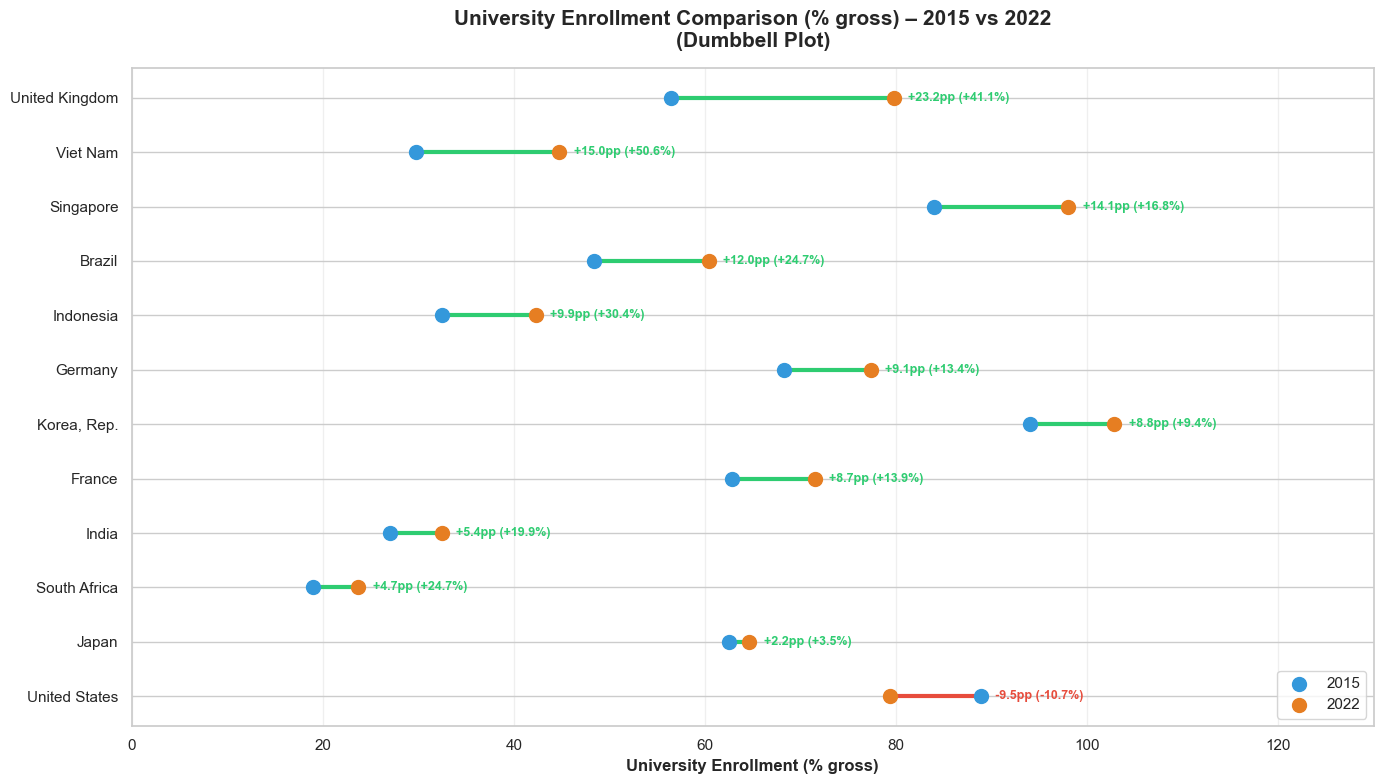


Top 5 countries with the highest growth rate (absolute change):
  United Kingdom       | 2015: 56.5% → 2022: 79.7% | Change: +23.2pp (+41.1%)
  Viet Nam             | 2015: 29.7% → 2022: 44.8% | Change: +15.0pp (+50.6%)
  Singapore            | 2015: 83.9% → 2022: 98.0% | Change: +14.1pp (+16.8%)
  Brazil               | 2015: 48.4% → 2022: 60.4% | Change: +12.0pp (+24.7%)
  Indonesia            | 2015: 32.5% → 2022: 42.3% | Change: +9.9pp (+30.4%)


In [26]:
# ====== CHART 3: DUMBBELL PLOT — University Enrollment Growth 2015 vs 2022 ======

ter_df = df_clean[df_clean['Series Code'] == 'SE.TER.ENRR'].copy()

# Get values for 2015 and 2022
ter_2015 = ter_df[ter_df['Year'] == 2015][['Country Name', 'Value']].rename(columns={'Value': 'Y2015'})
ter_2022 = ter_df[ter_df['Year'] == 2022][['Country Name', 'Value']].rename(columns={'Value': 'Y2022'})
dumbbell = ter_2015.merge(ter_2022, on='Country Name')
dumbbell['Change'] = dumbbell['Y2022'] - dumbbell['Y2015']
dumbbell['Change_pct'] = (dumbbell['Change'] / dumbbell['Y2015']) * 100
dumbbell = dumbbell.sort_values('Change', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 8))

# Draw connecting lines
for i, row in dumbbell.iterrows():
    color = '#2ecc71' if row['Change'] >= 0 else '#e74c3c'
    ax.plot([row['Y2015'], row['Y2022']], [i, i], color=color, linewidth=3, zorder=1)

# Draw points for 2015 and 2022
ax.scatter(dumbbell['Y2015'], range(len(dumbbell)), color='#3498db', s=100, zorder=2, label='2015')
ax.scatter(dumbbell['Y2022'], range(len(dumbbell)), color='#e67e22', s=100, zorder=2, label='2022')

# Annotate changes
for i, row in dumbbell.iterrows():
    sign = '+' if row['Change'] >= 0 else ''
    ax.annotate(f"{sign}{row['Change']:.1f}pp ({sign}{row['Change_pct']:.1f}%)",
                xy=(max(row['Y2015'], row['Y2022']) + 1.5, i),
                fontsize=9, va='center',
                color='#2ecc71' if row['Change'] >= 0 else '#e74c3c',
                fontweight='bold')

ax.set_yticks(range(len(dumbbell)))
ax.set_yticklabels(dumbbell['Country Name'], fontsize=11)
ax.set_xlabel('University Enrollment (% gross)', fontsize=12, fontweight='bold')
ax.set_title('University Enrollment Comparison (% gross) – 2015 vs 2022\n(Dumbbell Plot)',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, 130)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed table
print("\nTop 5 countries with the highest growth rate (absolute change):")
top5 = dumbbell.sort_values('Change', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Country Name']:20s} | 2015: {row['Y2015']:.1f}% → 2022: {row['Y2022']:.1f}% | Change: +{row['Change']:.1f}pp (+{row['Change_pct']:.1f}%)")

**Analysis of the Dumbbell Plot:**

**A. Top countries with the strongest growth:**

- **United Kingdom** has the largest absolute increase (~+23pp), from ~56% to ~80%, indicating a significant expansion of the tertiary education system.

- **Viet Nam** shows a notable increase (~+15pp, ~+50%), ranking among the fastest-growing countries.  
  --> This reflects efforts to expand access to higher education in a developing country.

- **Brazil**, **Indonesia**, **India** also record relatively large increases (~5–12pp), showing the trend of **expanding tertiary education** in developing countries.


**B. Countries with very high enrollment rates:**

- **Korea (South Korea)** and **Singapore** maintain very high levels (near or above 90%) and continue to increase.  
  --> This indicates that higher education has **almost reached universal coverage**.

**C. Special cases:**

- **United States** is the only country showing a **decline** (~-9.5pp), from ~89% to ~79%.  
  --> This may reflect the high cost of college education, leading to a trend of seeking alternative paths (vocational training, short-term certificates).


**D. General trend:**

- Developing countries (Asia, South America) are growing faster, showing a trend of **narrowing the gap in higher education access** compared to developed countries.

- However, despite rapid growth, current tertiary enrollment rates are still significantly lower than countries that have achieved high universal coverage.

**E. Insight for Viet Nam:**

Viet Nam is among the countries with **rapid growth in tertiary enrollment**, indicating that policies to expand education have been effective.

However, the absolute level (~45%) is still low compared to developed countries (70–100%).  
--> This shows that Viet Nam is in the **scale-up phase**, not yet reaching universal coverage.

--> In the coming period, Viet Nam needs to:
- Continue to **expand access to higher education**
- Meanwhile, focus on **improving education quality**, avoiding chasing quantity alone

## 2.3. Objective 3: Analyze the linear correlation between education investment and education access

### SMART Criteria:
- **S:** Answer the question: "Does spending more (% GDP) lead to a higher proportion of the population attending tertiary education?"
- **M:** Use the Pearson correlation coefficient $r$ between the two variables `SE.XPD.TOTL.GD.ZS` and `SE.TER.ENRR`.
- **A:** Easily calculated using Pandas and NumPy.
- **R:** Directly connects the two aspects of the topic: "Investment" and "Access."
- **T:** Summarized over the dataset period 2015–2022.

### Chart: Scatter Plot & Quadrant Analysis

**Reason for choosing the chart:**
To demonstrate correlation and tell a direct data story, **Scatter Plot** is graphically superior to a Combo Chart. Plotting 12 countries via bars and lines on dual axes heavily taxes the viewer's working memory. 
By assigning coordinates (Expenditure mapping to the X-axis, Enrollment mapping to the Y-axis), the mathematical relationship becomes instantly obvious at a glance: 
- The addition of a **Trendline** visually proves that the correlation is weak (the line is nearly flat, points are dispersed).
- Dividing the chart into **four target quadrants** via Median thresholds creates an immediate storytelling matrix: Who spends smartly? Who struggles? And most importantly, exactly where does **Vietnam** stand in the global layout?

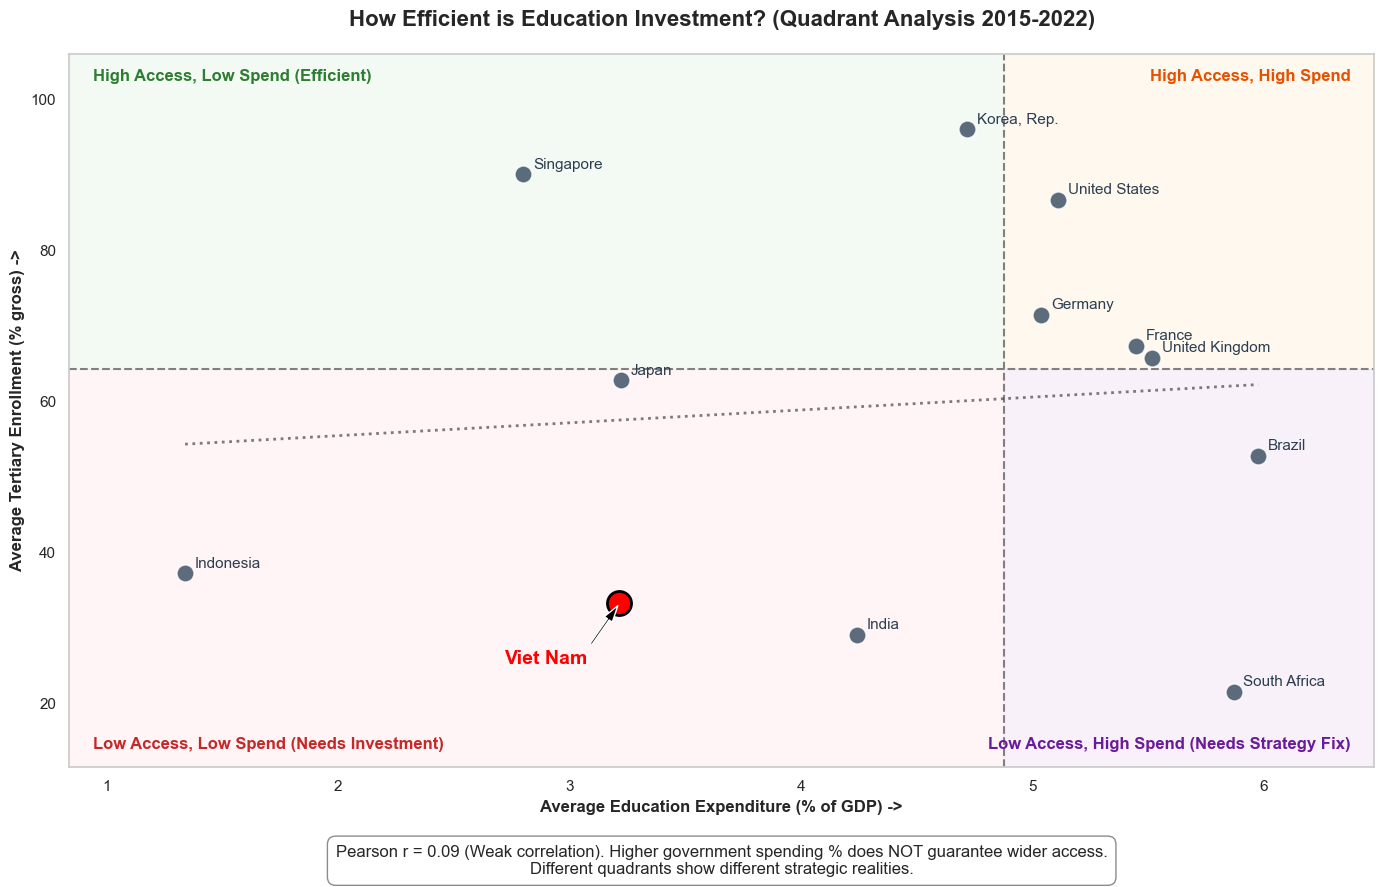


CORRELATION ANALYSIS RESULTS (Full Panel Data)
Pearson correlation r = 0.0911
p-value = 0.3774
Total observations: 96
→ Statistical conclusion: WEAK correlation (|r| < 0.3)


In [27]:
# ====== CHART 4: SCATTER PLOT & QUADRANT ANALYSIS — Education Investment vs Access ======

# Prepare data: pivot 3 variables per (country, year)
pivot_df = df_clean.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Code',
    values='Value'
).reset_index()
pivot_df.columns.name = None

# Rename columns
pivot_df = pivot_df.rename(columns={
    'SE.XPD.TOTL.GD.ZS': 'Edu_Expenditure',
    'SE.TER.ENRR': 'Tertiary_Enrollment',
    'NY.GDP.PCAP.CD': 'GDP_per_capita'
})

scatter_df = pivot_df.dropna(subset=['Edu_Expenditure', 'Tertiary_Enrollment', 'GDP_per_capita']).copy()
avg_df = scatter_df.groupby('Country Name')[['Edu_Expenditure', 'Tertiary_Enrollment']].mean().reset_index()

# Compute overall Pearson correlation
r_value, p_value = stats.pearsonr(scatter_df['Edu_Expenditure'], scatter_df['Tertiary_Enrollment'])

# Calculate medians for quadrants
med_x = avg_df['Edu_Expenditure'].median()
med_y = avg_df['Tertiary_Enrollment'].median()

plt.figure(figsize=(14, 9))

# 1. Clean background with quadrant dividing lines
plt.axvline(med_x, color='gray', linestyle='--', linewidth=1.5, zorder=1)
plt.axhline(med_y, color='gray', linestyle='--', linewidth=1.5, zorder=1)

# 2. Add soft background colors for the 4 quadrants to make them instantly obvious
axis_bounds = [avg_df['Edu_Expenditure'].min() - 0.5, avg_df['Edu_Expenditure'].max() + 0.5, 
               avg_df['Tertiary_Enrollment'].min() - 10, avg_df['Tertiary_Enrollment'].max() + 10]

# Top-Left: High Access, Low Spend (Ideal)
plt.axvspan(axis_bounds[0], med_x, ymin=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), ymax=1, 
            color='#e8f6e9', alpha=0.5, zorder=0)
plt.text(axis_bounds[0] + 0.1, axis_bounds[3] - 2, 'High Access, Low Spend (Efficient)', 
         color='#2e7d32', fontsize=12, fontweight='bold', va='top')

# Top-Right: High Access, High Spend
plt.axvspan(med_x, axis_bounds[1], ymin=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), ymax=1, 
            color='#fff3e0', alpha=0.5, zorder=0)
plt.text(axis_bounds[1] - 0.1, axis_bounds[3] - 2, 'High Access, High Spend', 
         color='#e65100', fontsize=12, fontweight='bold', ha='right', va='top')

# Bottom-Left: Low Access, Low Spend
plt.axvspan(axis_bounds[0], med_x, ymin=0, ymax=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), 
            color='#ffebee', alpha=0.5, zorder=0)
plt.text(axis_bounds[0] + 0.1, axis_bounds[2] + 2, 'Low Access, Low Spend (Needs Investment)', 
         color='#c62828', fontsize=12, fontweight='bold', va='bottom')

# Bottom-Right: Low Access, High Spend
plt.axvspan(med_x, axis_bounds[1], ymin=0, ymax=(med_y - axis_bounds[2])/(axis_bounds[3] - axis_bounds[2]), 
            color='#f3e5f5', alpha=0.5, zorder=0)
plt.text(axis_bounds[1] - 0.1, axis_bounds[2] + 2, 'Low Access, High Spend (Needs Strategy Fix)', 
         color='#6a1b9a', fontsize=12, fontweight='bold', ha='right', va='bottom')


# 3. Plot simple regression line to show lack of general correlation
sns.regplot(
    data=avg_df, x='Edu_Expenditure', y='Tertiary_Enrollment',
    scatter=False, color='black', ci=None, line_kws={'linestyle': ':', 'alpha': 0.5, 'linewidth': 2}
)

# 4. Scatter points with clear labels
for i, row in avg_df.iterrows():
    country = row['Country Name']
    x = row['Edu_Expenditure']
    y = row['Tertiary_Enrollment']
    
    # Highlight Viet Nam specifically
    if country == 'Viet Nam':
        plt.scatter(x, y, s=300, color='red', edgecolor='black', linewidth=2, zorder=5)
        # Add an arrow pointing exactly to Vietnam
        plt.annotate('Viet Nam', (x, y), xytext=(x - 0.5, y - 8),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                     fontsize=14, fontweight='bold', color='red', zorder=6)
    else:
        plt.scatter(x, y, s=150, color='#34495e', edgecolor='white', alpha=0.8, zorder=4)
        plt.annotate(country, (x, y), xytext=(7, 4), textcoords='offset points', 
                     fontsize=11, color='#2c3e50', zorder=5)

# 5. Conclusion text box
plt.text(0.5, -0.15,
        f'Pearson r = {r_value:.2f} (Weak correlation). Higher government spending % does NOT guarantee wider access.\nDifferent quadrants show different strategic realities.',
        transform=plt.gca().transAxes, fontsize=12, ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9), zorder=10)

plt.title('How Efficient is Education Investment? (Quadrant Analysis 2015-2022)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average Education Expenditure (% of GDP) ->', fontsize=12, fontweight='bold')
plt.ylabel('Average Tertiary Enrollment (% gross) ->', fontsize=12, fontweight='bold')

plt.xlim(axis_bounds[0], axis_bounds[1])
plt.ylim(axis_bounds[2], axis_bounds[3])

plt.grid(False) # Turn off grid to let the quadrant colors show cleanly
plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"CORRELATION ANALYSIS RESULTS (Full Panel Data)")
print(f"{'='*60}")
print(f"Pearson correlation r = {r_value:.4f}")
print(f"p-value = {p_value:.4f}")
print(f"Total observations: {len(scatter_df)}")
if abs(r_value) < 0.3:
    print(f"→ Statistical conclusion: WEAK correlation (|r| < 0.3)")
elif abs(r_value) < 0.5:
    print(f"→ Statistical conclusion: MEDIUM correlation (0.3 ≤ |r| < 0.5)")
elif abs(r_value) < 0.7:
    print(f"→ Statistical conclusion: FAIR correlation (0.5 ≤ |r| < 0.7)")
else:
    print(f"→ Statistical conclusion: STRONG correlation (|r| ≥ 0.7)")


**Analysis of the Scatter Plot (Quadrant Analysis):**

**A. Regarding the overall correlation (Trendline):**
- The dashed trendline is nearly flat and the points are widely, randomly dispersed around it. This visual strongly supports the Pearson r value (r < 0.3), indicating a weak linear relationship. This suggests that **higher relative government spending (% GDP) does not necessarily lead to higher tertiary enrollment rates.**

**B. Important Detailed Analysis:**
- **High Access / Low Spend (Top-Left):** **Singapore, Korea, Rep.**
  These systems sit efficiently in the top corner, achieving near-universal tertiary coverage (>90%) with relatively low public expenditure (% GDP). The hidden context here may reflect the role of private sector participation and differences in enormous absolute GDP numbers, effectively reducing the necessary percentage burden strictly from the public state budget.
- **Low Access / High Spend (Bottom-Right):** **South Africa, Brazil**
  Despite designating the largest relative slices of their economic pie to public education (>5.5%), their tertiary enrollment remains relatively low, compared to other countries in the dataset. Their specific coordinates strongly suggest structural inequities or a prioritized need to pump resources heavily into basic literacy and secondary education structurally prior to scaling universities.

**C. Viet Nam’s future strategies:**
- Vietnam is located in the **Low Access / Low Spend** quadrant.  
- This indicates that both tertiary access and public investment levels remain below the group average.  
- To improve tertiary participation, Vietnam may need to gradually increase public investment while also encouraging private sector involvement.

# 3. Summary of Education Investment and Access Analysis (2015–2022)

## 3.1. Education Investment (% GDP)

- **Overall trend:** Most countries maintain **stable or slightly decreasing spending** during 2015–2022. Education budgets are generally **stable**, with little short-term fluctuation.  
- **High spending group (>5% GDP):** South Africa shows a gradual increase, Brazil slightly decreases → developing countries prioritize education but must consider budget constraints.  
- **Medium/low spending group:** Vietnam (~2.9–3.5%) and some other Asian countries are lower, with a slight decreasing trend → **public investment share lags behind economic growth**, so gradual increases and integration with private resources are needed.  
- **COVID-19 impact:** Some countries show a slight increase in spending/GDP ratio, but need to check whether **GDP decline** or actual spending grows.  

**Insight for Vietnam:**  
- With a low-to-medium spending ratio, Vietnam needs to **gradually increase public investment** and **diversify funding sources (public–private)** to improve education quality without creating budget pressure.  

---

## 3.2. Higher Education Access

- **Rapid growth trend:** Developing countries like Vietnam, Brazil, Indonesia show increases of **15pp–23pp**, reflecting efforts to expand the university system.  
- **High coverage group:** Korea, Singapore (>90%), still increasing → systems nearly universal, most costs borne by private sector.  
- **Special case:** United States decreased (~-9.5pp) → high college costs may lead students to seek alternative paths.  

**Insight for Vietnam:**  
- Rapid growth (~+15pp, currently ~45%) → in the **expansion phase**, not yet universal.  
- Need to continue **expanding access** and **improving education quality**, avoiding quantity-driven policies.  

---

## 3.3. Spending–Access Correlation (Combo Chart)

- **Visual observation:** Education spending (% GDP) does not directly correspond to enrollment rates → **higher spending does not guarantee higher access**.  
- **Outliers:**  
  - Korea, Singapore: low % spending but very high enrollment → may be because of large absolute GDP and strong private sector participation.  
  - South Africa, Brazil: high spending but university enrollment is low → budget allocation may not be optimal or priority given to basic education first.  
- **Pearson r ≈ 0.09, p ≈ 0.38:** linear correlation **very weak and not significant**, confirming % GDP spending **is not the sole determining factor**.  

**Insight for Vietnam:**  
- Increasing % GDP spending does not ensure higher enrollment → need to consider:  
  - **Allocating budget efficiently across education levels**  
  - **Encouraging private education and appropriate tuition**  
  - **Investing simultaneously in quality and access**, not just total budget  